In [1]:
import pandas as pd

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv("Online-Retail.csv")

In [3]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df.shape

(541909, 8)

In [6]:
df = df.dropna(subset=['CustomerID'])

In [7]:
df.shape

(406829, 8)

In [8]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')] #cancelled orders removed

In [9]:
df.shape

(397924, 8)

In [10]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [11]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [12]:
customer_data = df.groupby("CustomerID").agg({
    "Quantity":"sum",
    "TotalAmount":"sum"
})

customer_data.head()


,Quantity,TotalAmount
CustomerID,,
12346.0,74215,77183.60
12347.0,2458,4310.00
12348.0,2341,1797.24
12349.0,631,1757.55
12350.0,197,334.40


In [13]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(customer_data)

In [14]:
#kmeans clustering
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

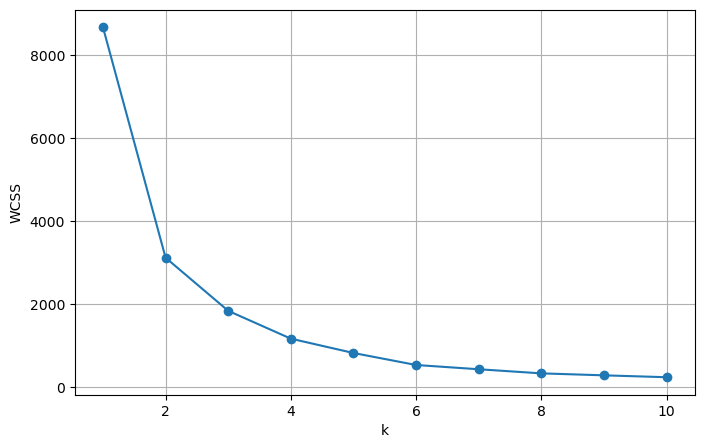

In [15]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [16]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_data["KMeans_Cluster"] = kmeans.fit_predict(scaled_data)

In [17]:
customer_data.head()

,Quantity,TotalAmount,KMeans_Cluster
CustomerID,,,
12346.0,74215,77183.60,2
12347.0,2458,4310.00,0
12348.0,2341,1797.24,0
12349.0,631,1757.55,0
12350.0,197,334.40,0


In [18]:
customer_data["KMeans_Cluster"].value_counts()

KMeans_Cluster
0    4302
2      30
1       6
Name: count, dtype: int64

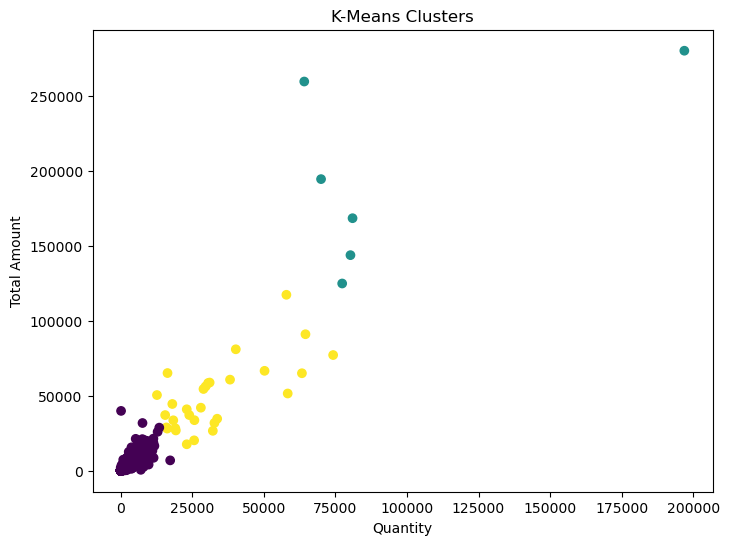

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    customer_data["Quantity"],
    customer_data["TotalAmount"],
    c=customer_data["KMeans_Cluster"],
    cmap="viridis"
)

plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.title("K-Means Clusters")

plt.show()

In [20]:
#herirarchical clusteing

hc = AgglomerativeClustering(
    n_clusters=3
)

customer_data["HC_Cluster"] = hc.fit_predict(scaled_data)

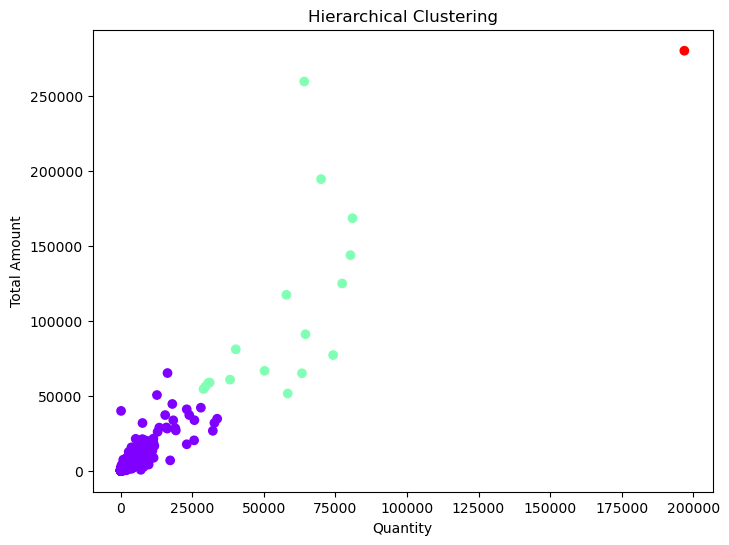

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    customer_data["Quantity"],
    customer_data["TotalAmount"],
    c=customer_data["HC_Cluster"],
    cmap="rainbow"
)

plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.title("Hierarchical Clustering")

plt.show()

In [22]:
customer_data.head()

,Quantity,TotalAmount,KMeans_Cluster,HC_Cluster
CustomerID,,,,
12346.0,74215,77183.60,2,1
12347.0,2458,4310.00,0,0
12348.0,2341,1797.24,0,0
12349.0,631,1757.55,0,0
12350.0,197,334.40,0,0
